Import the file

In [1]:
# import json
# with open('../data/bgg_RatingItem(4).jl', 'r') as source_file, open('../data/bgg_RatingItemCleaned.csv', 'w') as destination_file:

#     destination_file.write('bgg_id'+';;'+'bgg_user_name'+';;'+'bgg_user_rating'+'\n')
#     for line in source_file:
#         #print(line)
#         lineJson = json.loads(line)  # Load the JSON object to ensure it's valid
   
#         # Write the line to the destination file
#         if 'bgg_user_rating' in lineJson:
#             destination_file.write(str(lineJson['bgg_id'])+';'+str(lineJson['bgg_user_name'])+';'+str(lineJson['bgg_user_rating'])+'\n')
#         # else :
#         #     print("No user rating for bgg_id: ", lineJson['bgg_id'])


Calculate how many reviews were without a rating

In [2]:
with open('../data/bgg_RatingItem(4).jl', 'r') as source_file, open('../data/bgg_RatingItemCleaned.csv', 'r') as cleaned_file:
    line_count = sum(1 for _ in source_file)
    line_count_cleaned = sum(1 for _ in cleaned_file)
print(f"The file contains {line_count} lines.")
print(f"The file contains {line_count_cleaned} lines.")

The file contains 67220153 lines.
The file contains 27831518 lines.


In [3]:
import polars as pl

# Specify schema overrides for columns that should be strings (contain comma-separated values)
schema_overrides = {
    'implementation': pl.Utf8,
    'integration': pl.Utf8,
}

df_game_item_from_scraper = pl.read_csv('../data/bgg_GameItem(4).csv', quote_char='"', schema_overrides=schema_overrides)  # Does not contain expansion but contains moved game
df_game_item_from_bgg = pl.read_csv('../data/boardgames_ranks.csv')     # Does not contain moved game but contains expansion

# Filter rows where the 'bgg_id' column in df_game_item_from_scraper is not in df_game_item_from_bgg
filtered_rows = df_game_item_from_scraper.filter(~pl.col('bgg_id').is_in(df_game_item_from_bgg['id']))

# Display the filtered rows
print(filtered_rows.select(['bgg_id', 'name']))

shape: (736, 2)
┌────────┬─────────────────────────────────┐
│ bgg_id ┆ name                            │
│ ---    ┆ ---                             │
│ i64    ┆ str                             │
╞════════╪═════════════════════════════════╡
│ 2279   ┆ PowerTechnics                   │
│ 5116   ┆ Kreskin's ESP                   │
│ 6457   ┆ Hegemony                        │
│ 6736   ┆ Bonaparte                       │
│ 7183   ┆ Weapons & Warriors: Lashout La… │
│ …      ┆ …                               │
│ 451592 ┆ Kaito and Diamonds              │
│ 451593 ┆ Dog Bone Dog                    │
│ 453453 ┆ Andor legendái: Távoli föld     │
│ 453759 ┆ Reiss aus: Das mitreißende Par… │
│ 455308 ┆ This Is Not a Game About a Pip… │
└────────┴─────────────────────────────────┘


/tmp/ipykernel_19789/1036910517.py:13: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  filtered_rows = df_game_item_from_scraper.filter(~pl.col('bgg_id').is_in(df_game_item_from_bgg['id']))


Draw an histogram of the ratings

In [4]:
import polars as pl

# Read the cleaned file into a DataFrame using Polars
# Note: The header uses ';;' but data uses ';', so we skip header and provide column names
# Then select only the first 3 columns to avoid issues with the inconsistent header
df_cleaned = pl.read_csv(
    '../data/bgg_RatingItemCleaned.csv', 
    separator=';', 
    has_header=False,
    skip_rows=1,  # Skip the header line which has inconsistent separators
    new_columns=['bgg_id', 'bgg_user_name', 'bgg_user_rating']
).select(['bgg_id', 'bgg_user_name', 'bgg_user_rating'])  # Select only the 3 needed columns

df_cleaned = df_cleaned.with_columns(
    pl.col('bgg_user_rating').cast(pl.Float64, strict=False),
    pl.col('bgg_id').cast(pl.Float64, strict=False),
    pl.col('bgg_user_name').str.strip_chars()  # Remove leading/trailing spaces from usernames
)

In [5]:
# Find users with 10 or fewer reviews
user_review_counts = df_cleaned.group_by('bgg_user_name').count().rename({'count':'n_reviews'})
users_10_or_less = user_review_counts.filter(pl.col('n_reviews') <= 10)

print(f"Number of users with 10 or fewer reviews: {users_10_or_less.height}")

# Show a sample of such users and their review counts
print(users_10_or_less.sort('n_reviews', descending=True).head(20))

# Optional: show sample reviews from up to 3 such users
if users_10_or_less.height > 0:
    sample_users = users_10_or_less.sort('n_reviews').select('bgg_user_name').to_series().to_list()
    sample_users = sample_users[:3]
    for u in sample_users:
        print(f"\nSample reviews for user: {u}")
        print(df_cleaned.filter(pl.col('bgg_user_name') == u).select(['bgg_id','bgg_user_rating']).head(10))


/tmp/ipykernel_19789/2291249439.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  user_review_counts = df_cleaned.group_by('bgg_user_name').count().rename({'count':'n_reviews'})


Number of users with 10 or fewer reviews: 253267
shape: (20, 2)
┌─────────────────┬───────────┐
│ bgg_user_name   ┆ n_reviews │
│ ---             ┆ ---       │
│ str             ┆ u32       │
╞═════════════════╪═══════════╡
│ bearbullhawks   ┆ 10        │
│ standsix        ┆ 10        │
│ shifty isilwhit ┆ 10        │
│ wolfiklet       ┆ 10        │
│ hexton          ┆ 10        │
│ …               ┆ …         │
│ exqskarface     ┆ 10        │
│ trivdaddy       ┆ 10        │
│ scisteve        ┆ 10        │
│ cwilk           ┆ 10        │
│ aknorthroader   ┆ 10        │
└─────────────────┴───────────┘

Sample reviews for user: elteacher70
shape: (1, 2)
┌────────┬─────────────────┐
│ bgg_id ┆ bgg_user_rating │
│ ---    ┆ ---             │
│ f64    ┆ f64             │
╞════════╪═════════════════╡
│ 369.0  ┆ 10.0            │
└────────┴─────────────────┘

Sample reviews for user: sabieniewienie
shape: (1, 2)
┌──────────┬─────────────────┐
│ bgg_id   ┆ bgg_user_rating │
│ ---      ┆ ---    

In [6]:
import polars as pl

df_cleaned = df_cleaned.filter(~pl.col('bgg_id').is_in(filtered_rows['bgg_id']))


/tmp/ipykernel_19789/2718028821.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_cleaned = df_cleaned.filter(~pl.col('bgg_id').is_in(filtered_rows['bgg_id']))


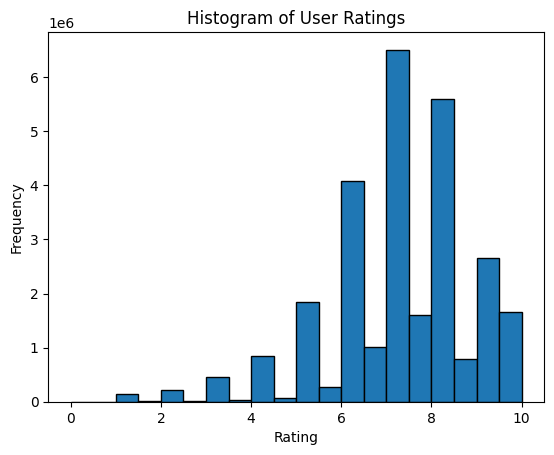

In [7]:
import polars as pl
import matplotlib.pyplot as plt

# Plot the histogram from Polars Series (drop nulls for plotting)
ratings = df_cleaned['bgg_user_rating'].drop_nulls().to_numpy()
plt.hist(ratings, bins=20, edgecolor='black')
plt.title('Histogram of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


/tmp/ipykernel_19789/3796006391.py:6: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  user_counts_df = df_cleaned.group_by('bgg_user_name').count().select(pl.col('count').alias('reviews'))
/tmp/ipykernel_19789/3796006391.py:9: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  review_distribution_df = user_counts_df.group_by('reviews').count().sort('reviews')


Text(0.5, 1.0, 'Distribution of Reviews per User')

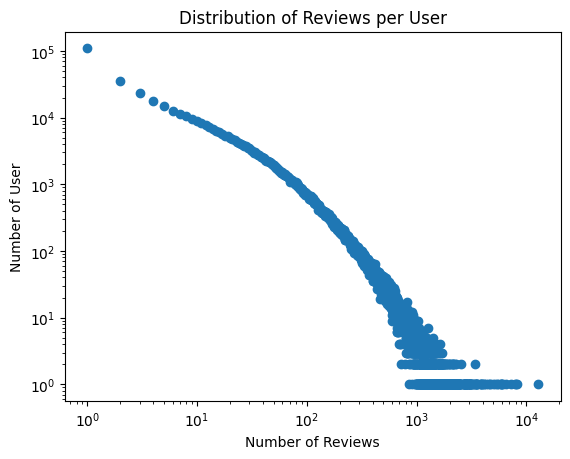

In [8]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Count how many reviews each user made
user_counts_df = df_cleaned.group_by('bgg_user_name').count().select(pl.col('count').alias('reviews'))

# Count the number of users for each review count
review_distribution_df = user_counts_df.group_by('reviews').count().sort('reviews')

x = review_distribution_df['reviews'].to_numpy()
y = review_distribution_df['count'].to_numpy()

plt.loglog(x, y, 'o')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of User')
plt.title('Distribution of Reviews per User')


Try to detect user that troll (extreme low ratings or high ratings)

In [9]:
# Define thresholds for extreme ratings
low_threshold = 1
high_threshold = 9

import polars as pl

# Filter users with extreme ratings
extreme_raters = df_cleaned.filter(
    (pl.col('bgg_user_rating') <= low_threshold) | (pl.col('bgg_user_rating') >= high_threshold)
)

# Group by user and count their extreme ratings
extreme_raters_count = extreme_raters.group_by('bgg_user_name').count().sort('count', descending=True)

# Display users with extreme ratings
print(extreme_raters_count)


shape: (475_238, 2)
┌───────────────┬───────┐
│ bgg_user_name ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ thebardgamer  ┆ 5028  │
│ the eraser    ┆ 2437  │
│ roncarlson01  ┆ 2427  │
│ richardingram ┆ 1491  │
│ eriksverker   ┆ 1366  │
│ …             ┆ …     │
│ berlinearl    ┆ 1     │
│ wabel         ┆ 1     │
│ albertgaspar  ┆ 1     │
│ vladimir97    ┆ 1     │
│ agak          ┆ 1     │
└───────────────┴───────┘


/tmp/ipykernel_19789/2781828587.py:13: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  extreme_raters_count = extreme_raters.group_by('bgg_user_name').count().sort('count', descending=True)


Show distribution of ratings

In [10]:
# Group by user and count their extreme ratings
df_cleaned_count = df_cleaned.group_by('bgg_user_name').count().sort('count', descending=True)

# Display users with extreme ratings
print(df_cleaned_count)

/tmp/ipykernel_19789/1855412987.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  df_cleaned_count = df_cleaned.group_by('bgg_user_name').count().sort('count', descending=True)


shape: (534_340, 2)
┌────────────────┬───────┐
│ bgg_user_name  ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ oldgoat3769967 ┆ 12813 │
│ himokl         ┆ 8306  │
│ warta          ┆ 7982  │
│ tomvasel       ┆ 7944  │
│ hessu68        ┆ 7329  │
│ …              ┆ …     │
│ sorkoth        ┆ 1     │
│ ethanroos      ┆ 1     │
│ tadpole667     ┆ 1     │
│ rocketart      ┆ 1     │
│ alexey_zverev  ┆ 1     │
└────────────────┴───────┘


/tmp/ipykernel_19789/633466494.py:6: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  game_review_counts = df_cleaned.group_by('bgg_id').count().select(pl.col('count').alias('reviews'))
/tmp/ipykernel_19789/633466494.py:9: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  review_dist = game_review_counts.group_by('reviews').count().sort('reviews')


Text(0.5, 1.0, 'Distribution of Reviews per Game')

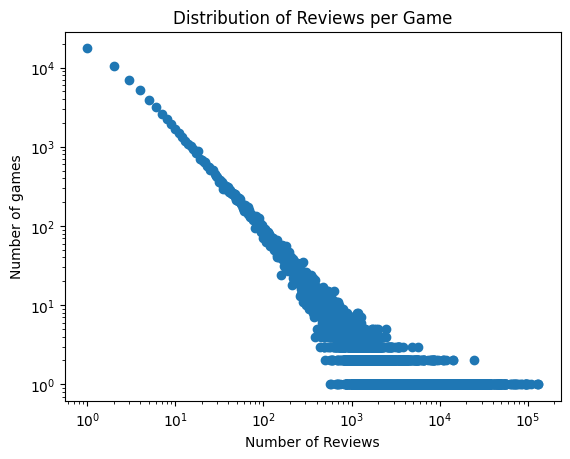

In [11]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Count the number of reviews for each game
game_review_counts = df_cleaned.group_by('bgg_id').count().select(pl.col('count').alias('reviews'))

# Count how many games have a specific number of reviews
review_dist = game_review_counts.group_by('reviews').count().sort('reviews')

x = review_dist['reviews'].to_numpy()
y = review_dist['count'].to_numpy()

plt.loglog(x, y, 'o')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of games')
plt.title('Distribution of Reviews per Game')


In [12]:
import polars as pl

# First, check for duplicates before aggregation
duplicates_check = df_cleaned.group_by(['bgg_id', 'bgg_user_name']).len().filter(pl.col('len') > 1).sort('len', descending=True)
print(f"Number of duplicate (bgg_id, bgg_user_name) pairs before aggregation: {duplicates_check.height}")
if duplicates_check.height > 0:
    print("\nDuplicates found:")
    print(duplicates_check)

# Aggregate duplicates by averaging the ratings
df_cleaned = df_cleaned.group_by(['bgg_id', 'bgg_user_name']).agg(
    pl.col('bgg_user_rating').mean()
)

print(f"\nAfter aggregation - Total rows: {df_cleaned.height}")

# Verify no duplicates remain
duplicates_after = df_cleaned.group_by(['bgg_id', 'bgg_user_name']).len().filter(pl.col('len') > 1)
print(f"Duplicates remaining after aggregation: {duplicates_after.height}")

Number of duplicate (bgg_id, bgg_user_name) pairs before aggregation: 1

Duplicates found:
shape: (1, 3)
┌─────────┬───────────────┬─────┐
│ bgg_id  ┆ bgg_user_name ┆ len │
│ ---     ┆ ---           ┆ --- │
│ f64     ┆ str           ┆ u32 │
╞═════════╪═══════════════╪═════╡
│ 17226.0 ┆ mycroft       ┆ 2   │
└─────────┴───────────────┴─────┘

After aggregation - Total rows: 27811174
Duplicates remaining after aggregation: 0


Remove game that have less than 100 Ratings

In [13]:
import time
import polars as pl

MIN_GAME_REVIEWS = 10
MIN_USER_REVIEWS = 2

print("Number of games before filtering:", df_cleaned['bgg_id'].n_unique(),
      "Number of reviews before filtering:", df_cleaned.height)

t0 = time.perf_counter()

# Step 1: Filter games with at least MIN_GAME_REVIEWS reviews
game_review_counts = df_cleaned.group_by('bgg_id').len()
valid_games = game_review_counts.filter(pl.col('len') >= MIN_GAME_REVIEWS)['bgg_id']
df_filtered_games = df_cleaned.join(valid_games.to_frame(), on='bgg_id', how='semi')
t1 = time.perf_counter()
print(f"Filtered games in {t1-t0:.2f}s; {df_filtered_games['bgg_id'].n_unique():,} games remain")

# Step 2: Filter users with at least MIN_USER_REVIEWS reviews
user_review_counts = df_filtered_games.group_by('bgg_user_name').len()
valid_users = user_review_counts.filter(pl.col('len') >= MIN_USER_REVIEWS)['bgg_user_name']
df_cleaned_with_threshold = df_filtered_games.join(valid_users.to_frame(), on='bgg_user_name', how='semi')
t2 = time.perf_counter()
print(f"Filtered users in {t2-t1:.2f}s; {df_cleaned_with_threshold['bgg_user_name'].n_unique():,} users remain")

print(
    "Number of games after filtering:", df_cleaned_with_threshold['bgg_id'].n_unique(),
    " Number of reviews after filtering:", df_cleaned_with_threshold.height
)


Number of games before filtering: 100231 Number of reviews before filtering: 27811174
Filtered games in 0.36s; 46,353 games remain
Filtered users in 1.27s; 423,087 users remain
Number of games after filtering: 46351  Number of reviews after filtering: 27534742


Write to file

In [14]:
from scipy.sparse import csr_matrix
import numpy as np

# Convert Polars DataFrame to pandas for categorical encoding
df_pandas = df_cleaned.to_pandas()

# Encode users and games
user_codes = df_pandas["bgg_user_name"].astype("category").cat.codes.values
game_codes = df_pandas["bgg_id"].astype("category").cat.codes.values
ratings = df_pandas["bgg_user_rating"].values.astype(np.float32)

n_users = user_codes.max() + 1
n_games = game_codes.max() + 1

R = csr_matrix(
    (ratings, (user_codes, game_codes)),
    shape=(n_users, n_games)
)
from sklearn.metrics.pairwise import cosine_similarity

rng = np.random.default_rng(42)

# sample games with enough ratings
game_popularity = np.diff(R.tocsc().indptr)
popular_games = np.where(game_popularity >= 100)[0]

sample_games = rng.choice(popular_games, size=500, replace=False)

# game vectors
X = R[:, sample_games].T  # shape: (n_games_sample, n_users)

baseline_sim = cosine_similarity(X)
def permute_ratings_within_users(R, seed=42):
    rng = np.random.default_rng(seed)
    R_perm = R.copy().tolil()

    for u in range(R_perm.shape[0]):
        row_data = R_perm.data[u]
        if len(row_data) > 1:
            rng.shuffle(row_data)

    return R_perm.tocsr()
R_perm = permute_ratings_within_users(R)

X_perm = R_perm[:, sample_games].T
perm_sim = cosine_similarity(X_perm)
from scipy.stats import spearmanr

# take upper triangle (unique pairs)
i, j = np.triu_indices_from(baseline_sim, k=1)

corr, _ = spearmanr(baseline_sim[i, j], perm_sim[i, j])
print(f"Spearman correlation (baseline vs permuted): {corr:.3f}")
# binary interaction matrix
R_bin = R.copy()
R_bin.data[:] = 1.0

X_bin = R_bin[:, sample_games].T
bin_sim = cosine_similarity(X_bin)

corr_bin, _ = spearmanr(
    baseline_sim[i, j],
    bin_sim[i, j]
)

print(f"Spearman correlation (rating vs binary): {corr_bin:.3f}")


Spearman correlation (baseline vs permuted): 0.984
Spearman correlation (rating vs binary): 0.985


In [15]:
import polars as pl

# Compute review counts per game
counts_df = df_cleaned.group_by('bgg_id').len()

# Example: fetch count for game id 420033
result = counts_df.filter(pl.col('bgg_id') == 420033)['len']
result[0] if len(result) > 0 else 0


1280

In [16]:
# Write using Polars - select only the 3 needed columns to avoid writing extra null columns
import polars as pl

df_cleaned_with_threshold.select(['bgg_id', 'bgg_user_name']).write_csv('../data/bgg_rating_threshold.csv', separator=';')